In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, roc_auc_score
import os

# Training and validation data

In [30]:
df_val = pd.read_csv(f'../260330_af3_benchmark/Supplementary_Tables/Supplementary_Table_1.csv')[['Epitope', 'TRAV', 'TRAJ', 'cdr3_TRA', 'TRBV', 'TRBJ', 'cdr3_TRB', 'dataset_source', 'Label']]
df_val = df_val.rename(columns={'Epitope' : 'model'})
df_val = df_val[df_val['dataset_source'].isin(['Public TCRs with undetermined specificities', 'Public Paired Data'])]

df_binders = pd.read_csv('All_models_TCRs.csv')

final_epitopes = []
for model, val_group in df_val.groupby('model'):
    if not (model.startswith('A') or model.startswith('B')):
        continue
    binders_group = df_binders[df_binders['model'] == model]
    if len(val_group) == 0 or len(binders_group) == 0:
        continue
    os.makedirs(model, exist_ok=True)
    val_group.to_csv(f'{model}/validation.csv', index=False)
    binders_group.to_csv(f'{model}/{model}.csv', index=False)
    final_epitopes.append(model)

with open('epitopes.txt', 'w') as f:
    f.write('\n'.join(final_epitopes))

print(f'{len(final_epitopes)} epitopes written to epitopes.txt')

81 epitopes written to epitopes.txt


# TEMPO training data

# Optimization

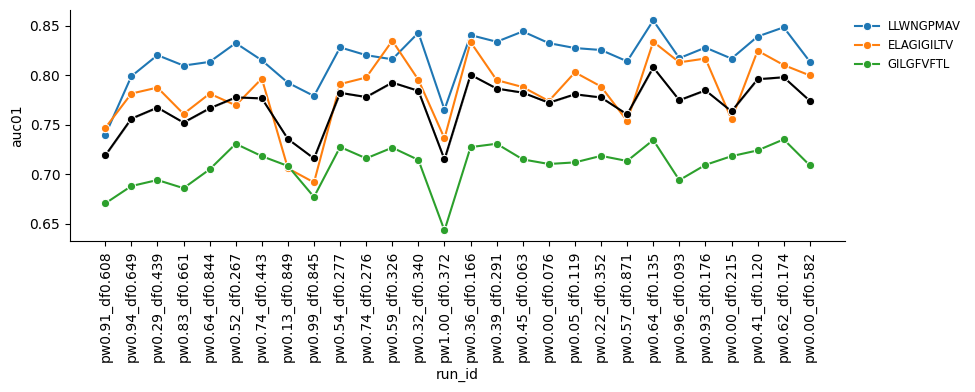

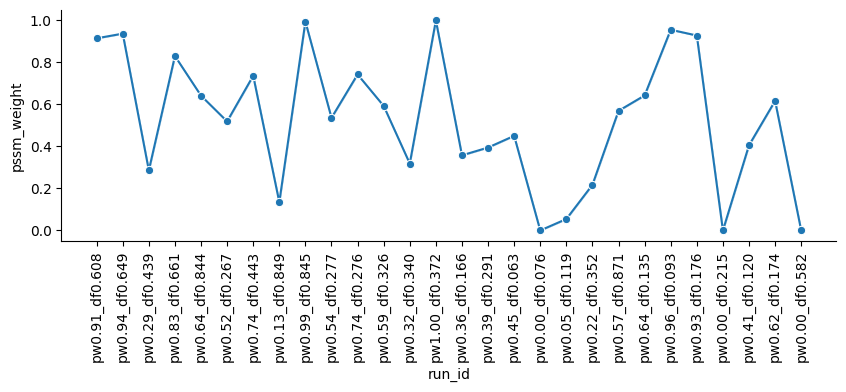

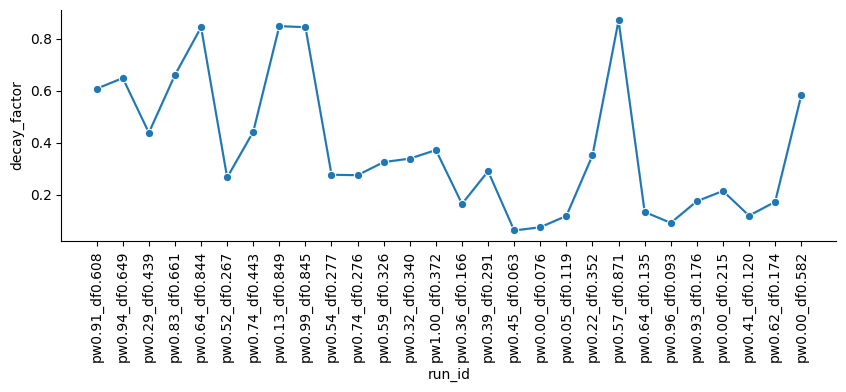

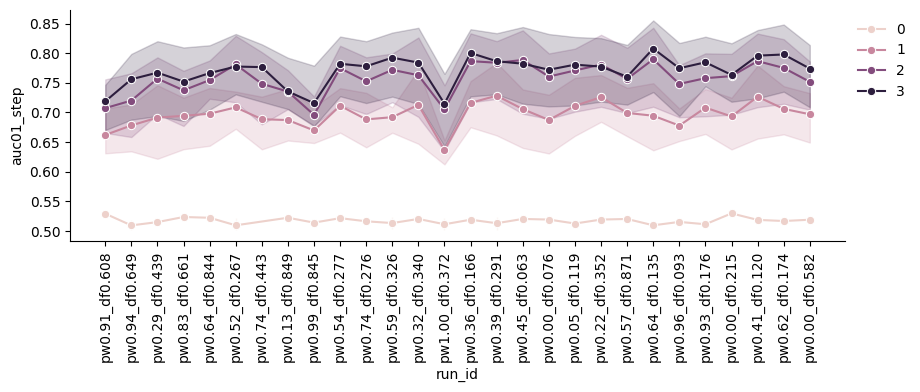

In [16]:
df = pd.read_csv('optimizer_runs/bayes_history.csv')

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
sns.lineplot(df, x='run_id', y='auc01', hue='peptide', ax=ax, marker='o')
sns.lineplot(df, x='run_id', y='mean_auc01', ax=ax, marker='o', color='black')
ax.tick_params(axis='x', rotation=90)

ax.legend(bbox_to_anchor=(1,1), frameon=False, fontsize='small')
sns.despine()

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
sns.lineplot(df, x='run_id', y='pssm_weight', ax=ax, marker='o')
ax.tick_params(axis='x', rotation=90)
sns.despine()

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
sns.lineplot(df, x='run_id', y='decay_factor', ax=ax, marker='o')
ax.tick_params(axis='x', rotation=90)
sns.despine()

df_long = df.melt(
    id_vars=['run_id', 'pssm_weight', 'decay_factor', 'mean_auc01', 'peptide', 'auc01'],
    value_vars=['auc01_step0', 'auc01_step1', 'auc01_step2', 'auc01_step3'],
    var_name='step',
    value_name='auc01_step'
)

df_long['step'] = df_long['step'].str.replace('auc01_step', '').astype(int)

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
sns.lineplot(df_long, x='run_id', y='auc01_step', hue='step', ax=ax, marker='o')
ax.tick_params(axis='x', rotation=90)
ax.legend(bbox_to_anchor=(1,1), frameon=False)
sns.despine()


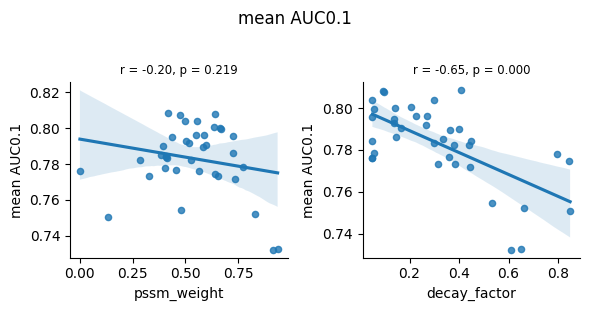

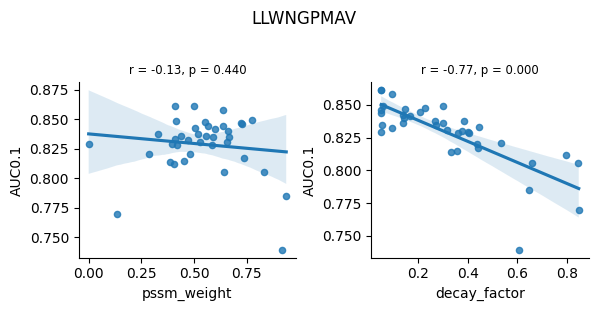

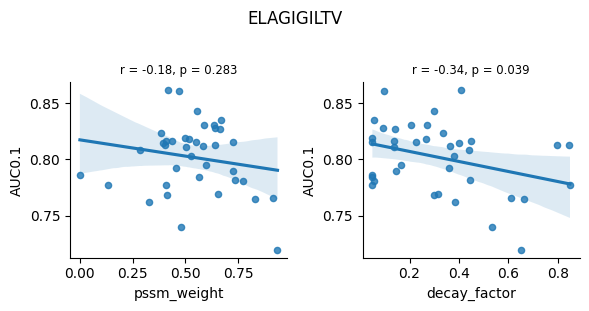

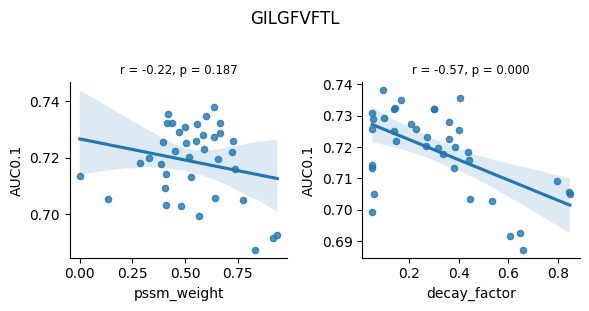

In [40]:
df = pd.read_csv('optimizer_runs/bayes_history.csv')
df = df[df['step'] == 3]

params = ['pssm_weight', 'decay_factor']
peptides = df['peptide'].unique()

# mean auc01 correlations
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, param in zip(axes, params):
    df_corr = df[['mean_auc01', param]].drop_duplicates()
    r, p = stats.pearsonr(df_corr[param], df_corr['mean_auc01'])
    sns.regplot(df_corr, x=param, y='mean_auc01', ax=ax, scatter_kws={'s': 20})
    ax.set_title(f'r = {r:.2f}, p = {p:.3f}', fontsize='small')
    ax.set_xlabel(param)
    ax.set_ylabel('mean AUC0.1')
plt.suptitle('mean AUC0.1', y=1.02)
plt.tight_layout()
sns.despine()

# per-peptide correlations
for peptide in peptides:
    df_pep = df[df['peptide'] == peptide]
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    for ax, param in zip(axes, params):
        r, p = stats.pearsonr(df_pep[param], df_pep['auc01'])
        sns.regplot(df_pep, x=param, y='auc01', ax=ax, scatter_kws={'s': 20})
        ax.set_title(f'r = {r:.2f}, p = {p:.3f}', fontsize='small')
        ax.set_xlabel(param)
        ax.set_ylabel('AUC0.1')
    plt.suptitle(peptide, y=1.02)
    plt.tight_layout()
    sns.despine()

# TEMPO AUC

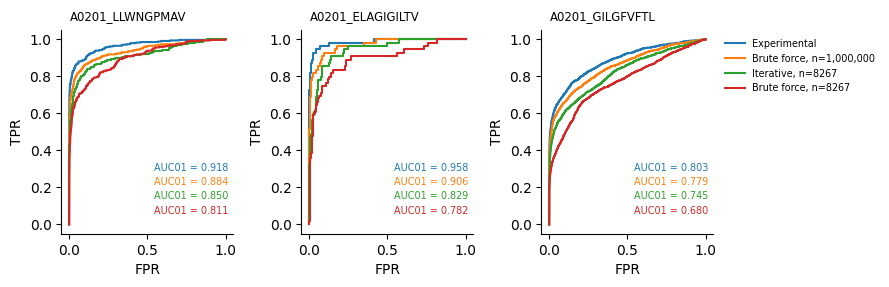

In [72]:
epitopes = ['A0201_LLWNGPMAV', 'A0201_ELAGIGILTV', 'A0201_GILGFVFTL']

sources = {
    'Experimental': lambda p: f'{p}/TEMPO_train_exp.csv',
    'Brute force, n=1,000,000': lambda p: f'brute_force_runs/{p}/validation/validation_pred.csv',
    'Iterative, n=8267': lambda p: f'{p}/validation/validation_pred.csv',
    'Brute force, n=8267': lambda p: f'brute_force_runs_small/{p}/validation/validation_pred.csv'
}

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

for cnt, epitope in enumerate(epitopes):
    ax = axes[cnt]
    ax.text(0.05, 1.1, epitope, transform=ax.transAxes, va='top', ha='left', fontsize='small')
    for i, (source_name, path_fn) in enumerate(sources.items()):
        df = pd.read_csv(path_fn(epitope))
        y_true, y_scores = df['Label'].values, df['score'].values
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)
        line, = ax.plot(fpr, tpr, label=source_name)
        ax.text(0.97, 0.3 - i * 0.07, f"AUC01 = {auc01:.3f}",
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize='x-small', color=line.get_color())

    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')

handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(handles, labels, fontsize='x-small', frameon=False,
                bbox_to_anchor=(1.02, 1), loc='upper left')

sns.despine()
plt.tight_layout()

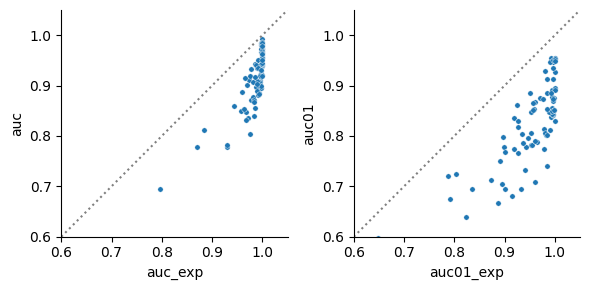

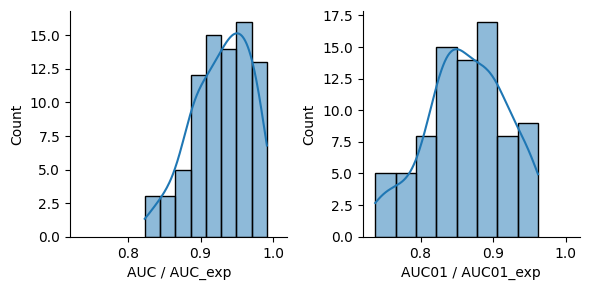

,epitope,auc,auc01,auc_exp,auc01_exp,n_tcrs_exp,ratio_auc,ratio_auc01
33,A0201_NLVPMVATV,0.694920,0.597711,0.795691,0.649130,6937,0.873354,0.920788
59,B0702_SPRWYFYYL,0.781368,0.639032,0.928910,0.823069,721,0.841166,0.776401
44,A0301_KTFPPTEPK,0.830688,0.667629,0.967930,0.887165,187,0.858211,0.752541
8,A0101_TTDPSFLGRY,0.778803,0.674080,0.928669,0.790436,474,0.838623,0.852794
73,B3501_IPSINVHHY,0.866957,0.681026,0.983831,0.914900,109,0.881205,0.744372
46,A1101_IVTDFSVIK,0.859820,0.694234,0.943564,0.835733,139,0.911247,0.830688
70,B1501_NQKLIANQF,0.838816,0.694461,0.984056,0.931833,87,0.852407,0.745264
18,A0201_CLGGLLTMV,0.803531,0.695646,0.976239,0.901146,156,0.823088,0.771957
4,A0101_LTDEMIAQY,0.836031,0.704268,0.970946,0.895138,137,0.861048,0.786770
36,A0201_RTATKQYNV,0.885346,0.708758,0.992591,0.961003,94,0.891955,0.737519


In [77]:
df1 = pd.read_csv('auc_summary.csv')
df2 = pd.read_csv('auc_summary_exp.csv')
df2 = df2.rename(columns={'auc': 'auc_exp', 'auc01': 'auc01_exp'})

df = pd.merge(df1, df2, on='epitope')

# number of experimental TCRs per epitope
def count_tcrs(epitope):
    path = f'{epitope}/{epitope}.csv'
    try:
        return len(pd.read_csv(path))
    except FileNotFoundError:
        return np.nan

df['n_tcrs_exp'] = df['epitope'].apply(count_tcrs)

# --- Figure 1: scatter plots ---
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

for ax, (x_col, y_col) in zip(axes, [('auc_exp', 'auc'), ('auc01_exp', 'auc01')]):
    sns.scatterplot(df, x=x_col, y=y_col, ax=ax, s=15)
    ax.axline((0, 0), slope=1, color='gray', linestyle=':')
    ax.set_xlim(0.60, 1.05)
    ax.set_ylim(0.60, 1.05)

sns.despine()
plt.tight_layout()
plt.show()

# --- Figure 2: ratio histograms ---
df['ratio_auc']   = df['auc']   / df['auc_exp']
df['ratio_auc01'] = df['auc01'] / df['auc01_exp']

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

for ax, col, label in zip(axes,
                           ['ratio_auc', 'ratio_auc01'],
                           ['AUC / AUC_exp', 'AUC01 / AUC01_exp']):
    sns.histplot(df[col], ax=ax, kde=True)
    ax.set_xlabel(label)

    ax.set_xlim(0.72, 1.02)
sns.despine()
plt.tight_layout()
plt.show()

df = df.sort_values(by='auc01')
df.head(20)

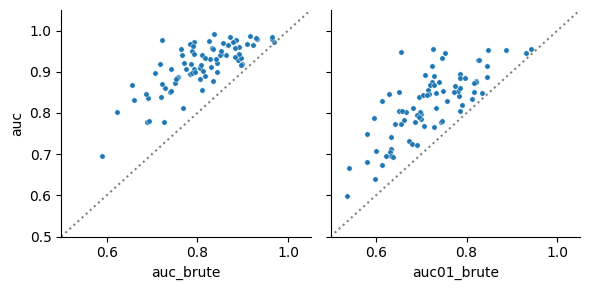

In [80]:
df1 = pd.read_csv('auc_summary.csv')
df2 = pd.read_csv('auc_summary_brute.csv')
df2 = df2.rename(columns={'auc': 'auc_brute', 'auc01': 'auc01_brute'})

df = pd.merge(df1, df2, on='epitope')

# number of experimental TCRs per epitope
def count_tcrs(epitope):
    path = f'{epitope}/{epitope}.csv'
    try:
        return len(pd.read_csv(path))
    except FileNotFoundError:
        return np.nan

df['n_tcrs_exp'] = df['epitope'].apply(count_tcrs)

# --- Figure 1: scatter plots ---
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharex=True, sharey=True)

for ax, (x_col, y_col) in zip(axes, [('auc_brute', 'auc'), ('auc01_brute', 'auc01')]):
    sns.scatterplot(df, x=x_col, y=y_col, ax=ax, s=15)
    ax.axline((0, 0), slope=1, color='gray', linestyle=':')
    ax.set_xlim(0.50, 1.05)
    ax.set_ylim(0.50, 1.05)

sns.despine()
plt.tight_layout()
plt.show()

# Optimize number of TCRs to score 

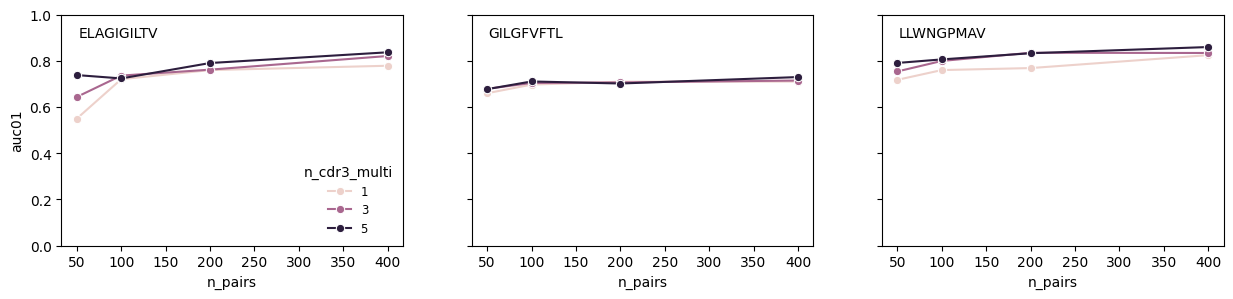

In [23]:
df = pd.read_csv('grid_search_runs/grid_results.csv')
df = df.sort_values(by='auc01', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 3), sharey=True)

for cnt, (peptide, group) in enumerate(df.groupby('peptide')):
    ax = axes[cnt]
    sns.lineplot(group, x='n_pairs', y='auc01', hue='n_cdr3_multi', ax=ax, marker='o',
                 legend=(cnt == 0))
    ax.text(0.05, 0.95, peptide, transform=ax.transAxes,
            fontsize=10, va='top', ha='left')
    if cnt == 0:
        ax.legend(title='n_cdr3_multi', loc='lower right', frameon=False, fontsize='small')

    ax.set_ylim(0, 1)


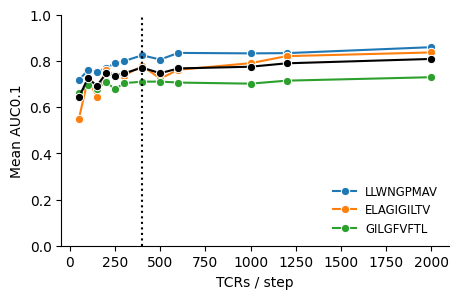

In [36]:
df['tcrs_per_step'] = df['n_pairs'] * df['n_cdr3_multi']
mean_df = df.groupby('tcrs_per_step')['auc01'].mean().reset_index()

fig, ax = plt.subplots(figsize=(5, 3))
sns.lineplot(mean_df, x='tcrs_per_step', y='auc01', marker='o', ax=ax, color='black', zorder=3)
sns.lineplot(df, x='tcrs_per_step', y='auc01', hue='peptide', marker='o', ax=ax)
ax.set_xlabel('TCRs / step')
ax.set_ylabel('Mean AUC0.1')
ax.set_ylim(0, 1)
ax.legend(loc='lower right', frameon=False, fontsize='small')
sns.despine()
ax.axvline(x=400, linestyle=':', color='black')